<a href="https://colab.research.google.com/github/ApoorvaBajpai/minor_integrated/blob/main/facial_branch_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 E-DAIC Facial Branch — Depression Detection from Facial AUs

**Pipeline:** Pre-extracted OpenFace 2.1.0 AU features → BiLSTM + Temporal Attention → 128-d embedding

| Step | What happens |
|------|--------------|
| 0 | Install packages & mount Drive |
| 1 | Explore AU data (plots & statistics) |
| 2 | Preprocess → padded sequences (N × 1500 × 17) |
| 3 | Train BiLSTM with 5-fold CV |
| 4 | Evaluate & export 128-d embeddings for fusion |

---
**Expected Drive layout before starting:**
```
Google Drive/edaic/
  facial_data/labels.csv          ← merged labels (275 participants)
  au_features/                    ← flat folder of AU CSVs from downloader
    300_OpenFace2.1.0_Pose_gaze_AUs.csv
    301_OpenFace2.1.0_Pose_gaze_AUs.csv
    ...
```

## ⚙️ Cell 0 — Setup

In [1]:
# Install packages
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q scikit-learn pandas numpy matplotlib seaborn tqdm

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import torch, os
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

# ─── EDIT THESE PATHS IF YOUR DRIVE LAYOUT IS DIFFERENT ─────────────────────
LABELS_CSV  = '/content/drive/MyDrive/edaic/facial_data/labels.csv'
AU_DIR      = '/content/drive/MyDrive/edaic/au_features'   # flat folder
WORK_DIR    = '/content/facial_work'                        # local scratch
# ─────────────────────────────────────────────────────────────────────────────

for d in [WORK_DIR, f'{WORK_DIR}/preprocessed', f'{WORK_DIR}/models']:
    os.makedirs(d, exist_ok=True)

print(f'\nLabels : {LABELS_CSV}')
print(f'AU dir  : {AU_DIR}')
print(f'Work    : {WORK_DIR}')

# Verify
import pandas as pd
labels = pd.read_csv(LABELS_CSV)
au_count = len([f for f in os.listdir(AU_DIR) if f.endswith('.csv')])
print(f'\n✅ Labels : {len(labels)} participants')
print(f'✅ AU files: {au_count} CSV files')

Mounted at /content/drive
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4

Labels : /content/drive/MyDrive/edaic/facial_data/labels.csv
AU dir  : /content/drive/MyDrive/edaic/au_features
Work    : /content/facial_work

✅ Labels : 275 participants
✅ AU files: 275 CSV files


## 📊 Cell 1 — Explore the AU Data

Total AU files found: 275
Sample file : 300_OpenFace2.1.0_Pose_gaze_AUs.csv
Total rows  : 19458
AU_r cols   : ['AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r']

Frame counts (high-conf, first 30 participants):
  Min=17682  Max=50975  Mean=26166


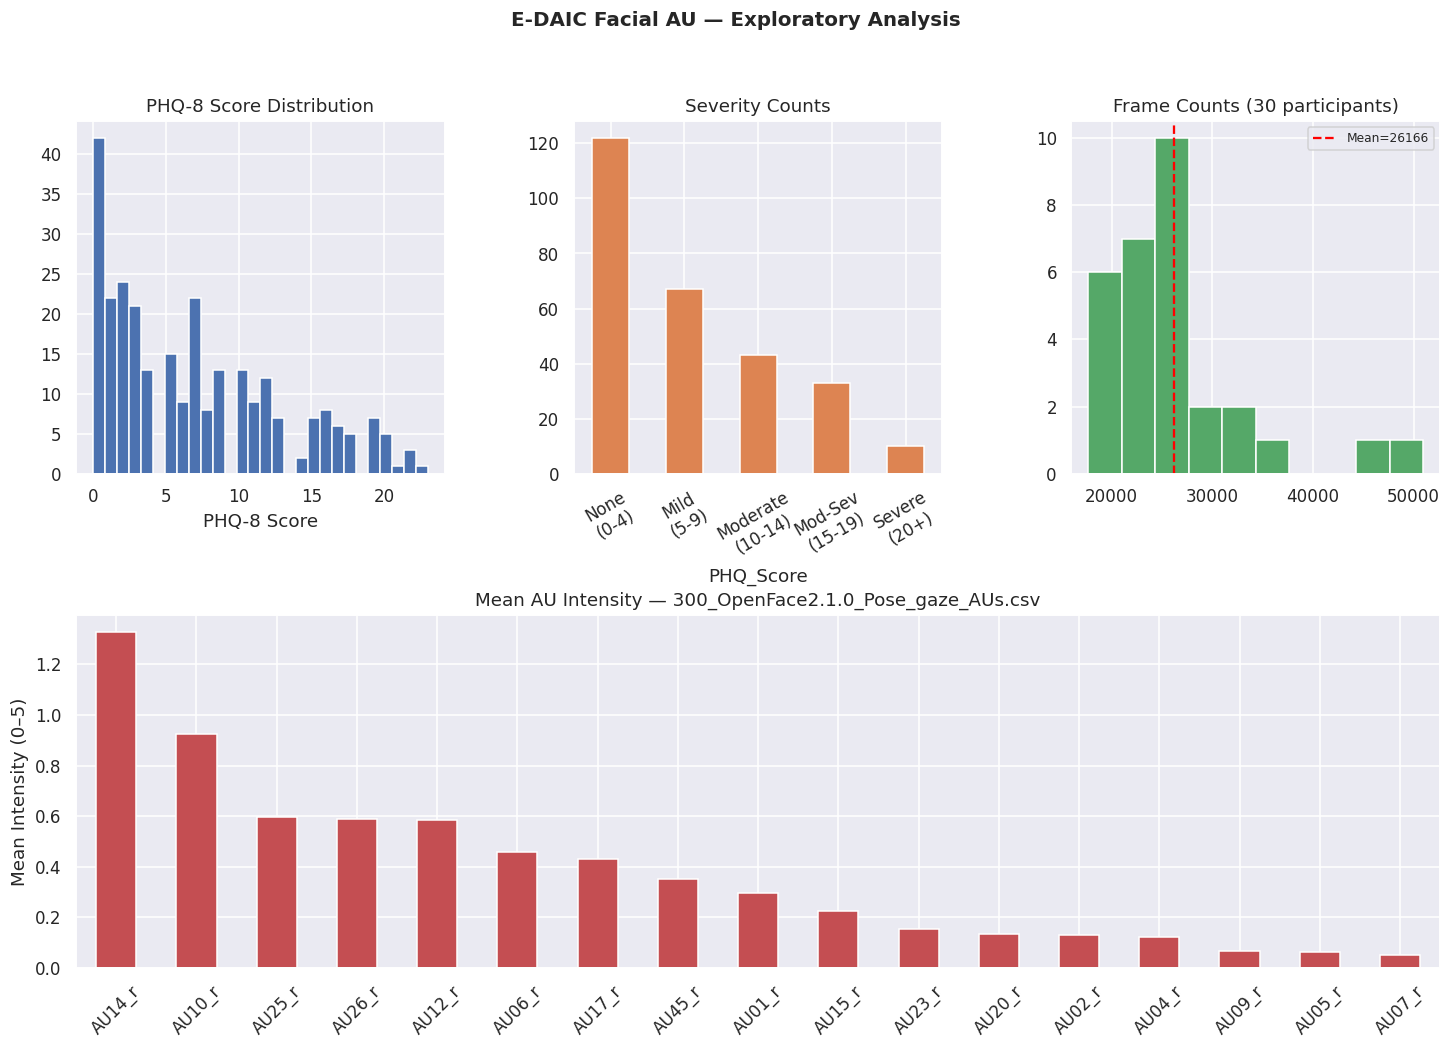

✅ Exploration complete


In [2]:
import glob, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, seaborn as sns

sns.set_theme(style='darkgrid'); plt.rcParams.update({'figure.dpi':110})

# ── Load one sample AU file to inspect columns ──────────────────────────────
au_files = sorted(glob.glob(os.path.join(AU_DIR, '*.csv')))
print(f'Total AU files found: {len(au_files)}')

sample = pd.read_csv(au_files[0])
sample.columns = sample.columns.str.strip()   # strip OpenFace leading spaces

AU_R = [c for c in sample.columns if c.startswith('AU') and c.endswith('_r')]
print(f'Sample file : {os.path.basename(au_files[0])}')
print(f'Total rows  : {len(sample)}')
print(f'AU_r cols   : {AU_R}')

# ── Frame count across first 30 participants ─────────────────────────────────
frame_counts = []
for fp in au_files[:30]:
    df = pd.read_csv(fp); df.columns = df.columns.str.strip()
    if 'confidence' in df.columns:
        df = df[df['confidence'] >= 0.75]
    frame_counts.append(len(df))

print(f'\nFrame counts (high-conf, first 30 participants):')
print(f'  Min={min(frame_counts)}  Max={max(frame_counts)}  Mean={np.mean(frame_counts):.0f}')

# ── Plots ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

# PHQ-8 distribution
ax1 = fig.add_subplot(gs[0, 0])
labels['PHQ_Score'].hist(bins=28, ax=ax1, color='#4c72b0', edgecolor='white')
ax1.set_title('PHQ-8 Score Distribution'); ax1.set_xlabel('PHQ-8 Score')

# Severity buckets
ax2 = fig.add_subplot(gs[0, 1])
bins_   = [0, 5, 10, 15, 20, 28]
labels_ = ['None\n(0-4)', 'Mild\n(5-9)', 'Moderate\n(10-14)', 'Mod-Sev\n(15-19)', 'Severe\n(20+)']
cats = pd.cut(labels['PHQ_Score'], bins=bins_, labels=labels_, right=False)
cats.value_counts().reindex(labels_).plot(kind='bar', ax=ax2, color='#dd8452', edgecolor='white')
ax2.set_title('Severity Counts'); ax2.tick_params(axis='x', rotation=30)

# Frame count histogram
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(frame_counts, bins=10, color='#55a868', edgecolor='white')
ax3.axvline(np.mean(frame_counts), color='red', linestyle='--',
            label=f'Mean={np.mean(frame_counts):.0f}')
ax3.set_title('Frame Counts (30 participants)'); ax3.legend(fontsize=8)

# AU mean intensities
ax4 = fig.add_subplot(gs[1, :])
means = sample[AU_R].mean().sort_values(ascending=False)
means.plot(kind='bar', ax=ax4, color='#c44e52', edgecolor='white')
ax4.set_title(f'Mean AU Intensity — {os.path.basename(au_files[0])}')
ax4.set_ylabel('Mean Intensity (0–5)'); ax4.tick_params(axis='x', rotation=45)

plt.suptitle('E-DAIC Facial AU — Exploratory Analysis', fontsize=13, fontweight='bold')
plt.savefig(f'{WORK_DIR}/exploration.png', bbox_inches='tight')
plt.show()
print('✅ Exploration complete')

## 🔧 Cell 2 — Preprocess AU Features

In [9]:
from pathlib import Path
from tqdm.notebook import tqdm

# ── Config ───────────────────────────────────────────────────────────────────
CONF_THRESHOLD = 0.75
FPS        = 30        # E-DAIC recording framerate
SAMPLE_FPS = 5         # downsample to reduce sequence length
SEQ_SEC    = 600       # use 5 minutes of interview
SEQ_LEN    = SEQ_SEC * SAMPLE_FPS   # = 1500 timesteps
STRIDE     = FPS // SAMPLE_FPS      # every 6th frame
OUT_DIR    = f'{WORK_DIR}/preprocessed'

print(f'Settings: {SEQ_LEN} timesteps @ {SAMPLE_FPS} fps ({SEQ_SEC}s window)')

# ── Build PID → file map  ────────────────────────────────────────────────────
au_files = sorted(glob.glob(os.path.join(AU_DIR, '*.csv')))

def get_pid(fp):
    return int(Path(fp).stem.split('_')[0])

file_map  = {get_pid(f): f for f in au_files}

# ── Detect AU columns from first file  ───────────────────────────────────────
first_df  = pd.read_csv(list(file_map.values())[0], nrows=2)
first_df.columns = first_df.columns.str.strip()
AU_COLS   = [c for c in first_df.columns if c.startswith('AU') and c.endswith('_r')]
NUM_AUS   = len(AU_COLS)
print(f'AU features ({NUM_AUS}): {AU_COLS}')

with open(f'{OUT_DIR}/au_feature_names.txt', 'w') as f:
    f.write('\n'.join(AU_COLS))

# ── Process participants ──────────────────────────────────────────────────────
def phq_severity(s):
    if s < 5:  return 0
    if s < 10: return 1
    if s < 15: return 2
    if s < 20: return 3
    return 4

seq_data, stat_data = [], []
phq_arr, bin_arr, sev_arr, pid_arr = [], [], [], []
skipped = []

for _, row in tqdm(labels.iterrows(), total=len(labels), desc='Processing'):
    pid = int(row['Participant_ID'])
    phq = float(row['PHQ_Score'])
    binary = int(row['PHQ_Binary'])

    if pid not in file_map:
        skipped.append(pid); continue

    df = pd.read_csv(file_map[pid])
    df.columns = df.columns.str.strip()   # OpenFace leading-space fix

    if 'confidence' in df.columns:
        df = df[df['confidence'] >= CONF_THRESHOLD].reset_index(drop=True)

    # Fill missing AU cols with 0
    for c in AU_COLS:
        if c not in df.columns: df[c] = 0.0

    au = df[AU_COLS].fillna(0.0).values          # (T, F)
    au = au[::STRIDE]                             # downsample

    # Per-participant z-normalise
    mu, sigma = au.mean(0, keepdims=True), au.std(0, keepdims=True) + 1e-8
    au_norm = au / 5.0

    # Pad / centre-crop to SEQ_LEN
    T = len(au_norm)
    if T >= SEQ_LEN:
        s = (T - SEQ_LEN) // 2
        seq = au_norm[s: s + SEQ_LEN]
    else:
        pad = np.zeros((SEQ_LEN - T, NUM_AUS))
        seq = np.vstack([au_norm, pad])

    # Statistical features (on raw values)
    stats = np.concatenate([au.mean(0), au.std(0), au.max(0), au.min(0)])

    seq_data.append(seq.astype(np.float32))
    stat_data.append(stats.astype(np.float32))
    phq_arr.append(phq); bin_arr.append(binary)
    sev_arr.append(phq_severity(phq)); pid_arr.append(pid)

print(f'\nProcessed : {len(seq_data)} | Skipped: {len(skipped)} {skipped}')

# ── Save ─────────────────────────────────────────────────────────────────────
np.save(f'{OUT_DIR}/au_sequences.npy',    np.array(seq_data))
np.save(f'{OUT_DIR}/au_stats.npy',        np.array(stat_data))
np.save(f'{OUT_DIR}/labels_phq.npy',      np.array(phq_arr,  dtype=np.float32))
np.save(f'{OUT_DIR}/labels_binary.npy',   np.array(bin_arr,  dtype=np.int64))
np.save(f'{OUT_DIR}/labels_severity.npy', np.array(sev_arr,  dtype=np.int64))
np.save(f'{OUT_DIR}/participant_ids.npy', np.array(pid_arr))

X = np.array(seq_data)
print(f'\n✅ Saved arrays:')
print(f'   au_sequences  : {X.shape}  (N × SEQ_LEN × NUM_AUS)')
print(f'   labels_phq    : {len(phq_arr)} values, range {min(phq_arr):.0f}–{max(phq_arr):.0f}')
print(f'   Severity dist : {dict(zip(*np.unique(sev_arr, return_counts=True)))}')

Settings: 3000 timesteps @ 5 fps (600s window)
AU features (17): ['AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r']


Processing:   0%|          | 0/275 [00:00<?, ?it/s]


Processed : 275 | Skipped: 0 []

✅ Saved arrays:
   au_sequences  : (275, 3000, 17)  (N × SEQ_LEN × NUM_AUS)
   labels_phq    : 275 values, range 0–23
   Severity dist : {np.int64(0): np.int64(122), np.int64(1): np.int64(67), np.int64(2): np.int64(43), np.int64(3): np.int64(33), np.int64(4): np.int64(10)}


## 🏋️ Cell 3 — Train BiLSTM Model (5-Fold CV)

In [10]:
import torch, torch.nn as nn, torch.nn.functional as F, json
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, mean_absolute_error, mean_squared_error
# Add this as the VERY FIRST line of Cell 3:
import torch.nn.functional as F_torch

# And replace all F.softmax in TemporalAttn with:
# return (F_torch.softmax(self.w(x), dim=1) * x).sum(1)


# ── Config ───────────────────────────────────────────────────────────────────
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED       = 42
N_FOLDS    = 5
BATCH_SIZE = 16
EPOCHS     = 40
LR         = 3e-4
PATIENCE   = 8
EMBED_DIM  = 128     # must match text branch
MODEL_DIR  = f'{WORK_DIR}/models'
OUT_DIR    = f'{WORK_DIR}/preprocessed'

torch.manual_seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}')

# ── Load data ─────────────────────────────────────────────────────────────────
X_seq = np.load(f'{OUT_DIR}/au_sequences.npy')
y_phq = np.load(f'{OUT_DIR}/labels_phq.npy')
y_sev = np.load(f'{OUT_DIR}/labels_severity.npy')
pids  = np.load(f'{OUT_DIR}/participant_ids.npy')
N, T, n_feat = X_seq.shape
NUM_CLASSES = len(np.unique(y_sev))
print(f'Data: {X_seq.shape}  |  Classes: {NUM_CLASSES}')

# ── Dataset ───────────────────────────────────────────────────────────────────
class AUDataset(Dataset):
    def __init__(self, X, yp, ys):
        self.X = torch.FloatTensor(X)
        self.yp = torch.FloatTensor(yp)
        self.ys = torch.LongTensor(ys)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.yp[i], self.ys[i]

# ── Model ─────────────────────────────────────────────────────────────────────
class TemporalAttn(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.w = nn.Linear(d, 1)
    def forward(self, x):   # x: (B, T, H)
        return (F.softmax(self.w(x), dim=1) * x).sum(1)

class FacialLSTM(nn.Module):
    def __init__(self, in_dim, h1=128, h2=64, embed=128, n_class=5, drop=0.4):
        super().__init__()
        self.lstm1 = nn.LSTM(in_dim, h1, batch_first=True, bidirectional=True, dropout=drop)
        self.ln1   = nn.LayerNorm(h1*2)
        self.lstm2 = nn.LSTM(h1*2, h2, batch_first=True, bidirectional=True, dropout=drop)
        self.ln2   = nn.LayerNorm(h2*2)
        self.attn  = TemporalAttn(h2*2)
        self.drop  = nn.Dropout(drop)
        self.proj  = nn.Sequential(nn.Linear(h2*2, embed), nn.GELU(), nn.LayerNorm(embed))
        self.regr  = nn.Linear(embed, 1)
        self.cls   = nn.Linear(embed, n_class)

    def forward(self, x, emb_only=False):
        o, _ = self.lstm1(x);  o = self.ln1(o)
        o, _ = self.lstm2(o);  o = self.ln2(o)
        o    = self.attn(o);   o = self.drop(o)
        e    = self.proj(o)
        if emb_only: return e
        return self.regr(e).squeeze(-1), self.cls(e), e

# ── Loss ──────────────────────────────────────────────────────────────────────
class Loss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha=alpha; self.mse=nn.MSELoss(); self.ce=nn.CrossEntropyLoss()
    def forward(self, pp, pt, sp, st):
        return self.mse(pp, pt) + self.alpha * self.ce(sp, st)

def make_sampler(ys):
    cls, cnt = np.unique(ys, return_counts=True)
    wmap = {c: 1/n for c,n in zip(cls,cnt)}
    w = torch.FloatTensor([wmap[s] for s in ys])
    return WeightedRandomSampler(w, len(w))

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    pp_all, pt_all, sp_all, st_all, embs = [], [], [], [], []
    total_loss = 0
    for X, yp, ys in loader:
        X,yp,ys = X.to(DEVICE), yp.to(DEVICE), ys.to(DEVICE)
        pp, sp, e = model(X)
        total_loss += criterion(pp, yp, sp, ys).item()
        pp_all += pp.cpu().tolist(); pt_all += yp.cpu().tolist()
        sp_all += sp.argmax(-1).cpu().tolist(); st_all += ys.cpu().tolist()
        embs.append(e.cpu().numpy())
    pp_all = np.clip(pp_all, 0, 27)
    mae  = mean_absolute_error(pt_all, pp_all)
    rmse = np.sqrt(mean_squared_error(pt_all, pp_all))
    f1   = f1_score(st_all, sp_all, average='macro', zero_division=0)
    return total_loss/len(loader), mae, rmse, f1, np.array(sp_all), np.array(st_all), np.vstack(embs)

# ── 5-Fold Training ───────────────────────────────────────────────────────────
print(f'\nStarting {N_FOLDS}-fold cross-validation...')
skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)

all_embs  = np.zeros((N, EMBED_DIM), dtype=np.float32)
fold_results = []
best_f1, best_fold = -1, 1

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_seq, y_sev)):
    print(f'\n── Fold {fold+1}/{N_FOLDS} ──')

    tr_ds  = AUDataset(X_seq[tr_idx],  y_phq[tr_idx],  y_sev[tr_idx])
    val_ds = AUDataset(X_seq[val_idx], y_phq[val_idx], y_sev[val_idx])
    tr_loader  = DataLoader(tr_ds,  BATCH_SIZE, sampler=make_sampler(y_sev[tr_idx]),
                            num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True)

    model = FacialLSTM(n_feat, n_class=NUM_CLASSES).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS)
    crit  = Loss()
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))

    best_vloss, no_imp = 9e9, 0

    for ep in range(EPOCHS):
        model.train()
        tl = 0
        for X, yp, ys in tr_loader:
            X,yp,ys = X.to(DEVICE), yp.to(DEVICE), ys.to(DEVICE)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):
                pp, sp, _ = model(X)
                loss = crit(pp, yp, sp, ys)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            tl += loss.item()
        sched.step()
        tl /= len(tr_loader)

        vl, mae, rmse, f1, *_ = evaluate(model, val_loader, crit)
        print(f'  ep{ep+1:2d}  train={tl:.3f}  val={vl:.3f}  MAE={mae:.2f}  F1={f1:.3f}')

        if vl < best_vloss:
            best_vloss, no_imp = vl, 0
            torch.save(model.state_dict(), f'{MODEL_DIR}/fold{fold+1}.pt')
        else:
            no_imp += 1
            if no_imp >= PATIENCE: print(f'  Early stop'); break

    # Reload best & get embeddings
    model.load_state_dict(torch.load(f'{MODEL_DIR}/fold{fold+1}.pt', map_location=DEVICE))
    vl, mae, rmse, f1, _, _, embs = evaluate(model, val_loader, crit)
    all_embs[val_idx] = embs

    fold_results.append({'fold':fold+1,'mae':mae,'rmse':rmse,'f1':f1})
    print(f'  FOLD {fold+1} FINAL → MAE={mae:.3f}  RMSE={rmse:.3f}  F1={f1:.3f}')

    if f1 > best_f1:
        best_f1, best_fold = f1, fold+1
        torch.save(model.state_dict(), f'{MODEL_DIR}/facial_lstm_best.pt')

# ── Summary ───────────────────────────────────────────────────────────────────
maes  = [r['mae']  for r in fold_results]
rmses = [r['rmse'] for r in fold_results]
f1s   = [r['f1']   for r in fold_results]

print(f'\n{"="*50}')
print(f'CROSS-VALIDATION RESULTS ({N_FOLDS} folds)')
print(f'  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}')
print(f'  RMSE     : {np.mean(rmses):.3f} ± {np.std(rmses):.3f}')
print(f'  F1-macro : {np.mean(f1s):.3f} ± {np.std(f1s):.3f}')
print(f'  Best fold: {best_fold}')
print(f'{"="*50}')

# Save results
with open(f'{MODEL_DIR}/facial_results.json','w') as f:
    json.dump({'fold_results':fold_results,
               'mean_mae':float(np.mean(maes)), 'std_mae':float(np.std(maes)),
               'mean_f1':float(np.mean(f1s)),   'std_f1':float(np.std(f1s))}, f, indent=2)

# Save OOF embeddings
np.save(f'{MODEL_DIR}/facial_embeddings_oof.npy', all_embs)
np.save(f'{MODEL_DIR}/participant_ids.npy', pids)
print(f'\n✅ OOF embeddings saved: {all_embs.shape}')

Device: cuda
Data: (275, 3000, 17)  |  Classes: 5

Starting 5-fold cross-validation...

── Fold 1/5 ──


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
/tmp/ipykernel_2265/630771408.py:128: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))
/tmp/ipykernel_2265/630771408.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):


  ep 1  train=184.528  val=47.482  MAE=5.25  F1=0.167


/tmp/ipykernel_2265/630771408.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):


  ep 2  train=114.300  val=38.685  MAE=5.15  F1=0.125


...

  ep10  train=57.186  val=48.158  MAE=5.79  F1=0.112


/tmp/ipykernel_2265/630771408.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):


  ep11  train=54.029  val=50.510  MAE=5.96  F1=0.076


/tmp/ipykernel_2265/630771408.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):


  ep12  train=57.346  val=52.204  MAE=6.06  F1=0.076
  Early stop
  FOLD 5 FINAL → MAE=5.038  RMSE=5.903  F1=0.122

CROSS-VALIDATION RESULTS (5 folds)
  MAE      : 5.124 ± 0.101
  RMSE     : 6.116 ± 0.138
  F1-macro : 0.126 ± 0.037
  Best fold: 3

✅ OOF embeddings saved: (275, 128)


## 📈 Cell 4 — Evaluate & Export Embeddings for Fusion

✅ Best model loaded


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)



  PHQ-8 MAE           : 5.069
  PHQ-8 RMSE          : 6.101
  F1-macro (5-class)  : 0.088
  F1 (binary)         : 0.000  ← key metric for paper

              precision    recall  f1-score   support

        None       0.00      0.00      0.00       122
        Mild       0.00      0.00      0.00        67
        Mod.       0.16      1.00      0.27        43
     Mod-Sev       0.00      0.00      0.00        33
      Severe       0.50      0.10      0.17        10

    accuracy                           0.16       275
   macro avg       0.13      0.22      0.09       275
weighted avg       0.04      0.16      0.05       275


✅ facial_embeddings_all.npy  shape=(275, 128)


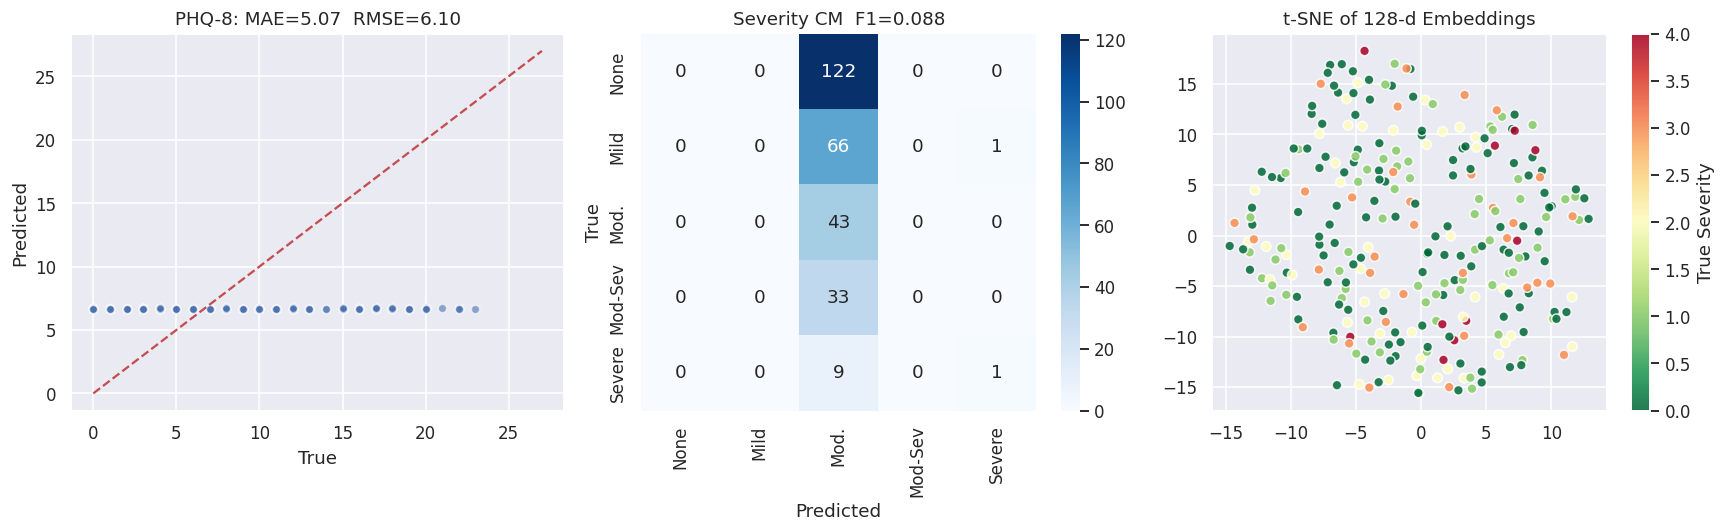

✅ Saved to Drive → /content/drive/MyDrive/edaic/fusion_inputs

🎉 FACIAL BRANCH COMPLETE! Embeddings shape: (275, 128)
   Binary F1 = 0.000  |  MAE = 5.069
   Next step: Fusion notebook with MentalBERT embeddings


In [11]:
import torch, torch.nn as nn
import torch.nn.functional as F_func
import numpy as np, pandas as pd, os, json
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, mean_absolute_error, mean_squared_error)
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
EMBED_DIM  = 128
MODEL_DIR  = f'{WORK_DIR}/models'
OUT_DIR    = f'{WORK_DIR}/preprocessed'
BATCH_SIZE = 16

# ── Re-define classes (with F_func fix) ──────────────────────────────────────
class AUDataset(Dataset):
    def __init__(self, X, yp, ys):
        self.X=torch.FloatTensor(X); self.yp=torch.FloatTensor(yp); self.ys=torch.LongTensor(ys)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.yp[i], self.ys[i]

class TemporalAttn(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.w = nn.Linear(d, 1)
    def forward(self, x):
        return (F_func.softmax(self.w(x), dim=1) * x).sum(1)  # ← F_func, not F

class FacialLSTM(nn.Module):
    def __init__(self, in_dim, h1=128, h2=64, embed=128, n_class=5, drop=0.4):
        super().__init__()
        self.lstm1 = nn.LSTM(in_dim, h1, batch_first=True, bidirectional=True, dropout=drop)
        self.ln1   = nn.LayerNorm(h1*2)
        self.lstm2 = nn.LSTM(h1*2, h2, batch_first=True, bidirectional=True, dropout=drop)
        self.ln2   = nn.LayerNorm(h2*2)
        self.attn  = TemporalAttn(h2*2)
        self.drop  = nn.Dropout(drop)
        self.proj  = nn.Sequential(nn.Linear(h2*2, embed), nn.GELU(), nn.LayerNorm(embed))
        self.regr  = nn.Linear(embed, 1)
        self.cls   = nn.Linear(embed, n_class)
    def forward(self, x, emb_only=False):
        o,_ = self.lstm1(x); o = self.ln1(o)
        o,_ = self.lstm2(o); o = self.ln2(o)
        o   = self.attn(o);  o = self.drop(o)
        e   = self.proj(o)
        if emb_only: return e
        return self.regr(e).squeeze(-1), self.cls(e), e

# ── Load data ──────────────────────────────────────────────────────────────────
X_seq = np.load(f'{OUT_DIR}/au_sequences.npy')
y_phq = np.load(f'{OUT_DIR}/labels_phq.npy')
y_sev = np.load(f'{OUT_DIR}/labels_severity.npy')
y_bin = np.load(f'{OUT_DIR}/labels_binary.npy')
pids  = np.load(f'{OUT_DIR}/participant_ids.npy')
N, T, n_feat = X_seq.shape
NUM_CLASSES  = len(np.unique(y_sev))

# ── Load best model ────────────────────────────────────────────────────────────
best_model = FacialLSTM(n_feat, n_class=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(torch.load(f'{MODEL_DIR}/facial_lstm_best.pt', map_location=DEVICE))
best_model.eval()
print('✅ Best model loaded')

# ── Inference ──────────────────────────────────────────────────────────────────
full_ds  = AUDataset(X_seq, y_phq, y_sev)
full_ldr = DataLoader(full_ds, BATCH_SIZE, shuffle=False)
pp_all, pt_all, sp_all, st_all, emb_all = [], [], [], [], []
with torch.no_grad():
    for X, yp, ys in full_ldr:
        pp, sp, e = best_model(X.to(DEVICE))
        pp_all += np.clip(pp.cpu().numpy(), 0, 27).tolist()
        pt_all += yp.tolist()
        sp_all += sp.argmax(-1).cpu().tolist()
        st_all += ys.tolist()
        emb_all.append(e.cpu().numpy())

pp_all = np.array(pp_all); pt_all = np.array(pt_all)
sp_all = np.array(sp_all); st_all = np.array(st_all)
embeddings = np.vstack(emb_all)

# ── Metrics ────────────────────────────────────────────────────────────────────
mae   = mean_absolute_error(pt_all, pp_all)
rmse  = np.sqrt(mean_squared_error(pt_all, pp_all))
f1_5  = f1_score(st_all, sp_all, average='macro', zero_division=0)
f1_bin= f1_score(y_bin, (pp_all>=10).astype(int), average='binary', zero_division=0)
sev_names = ['None','Mild','Mod.','Mod-Sev','Severe'][:NUM_CLASSES]

print(f'\n  PHQ-8 MAE           : {mae:.3f}')
print(f'  PHQ-8 RMSE          : {rmse:.3f}')
print(f'  F1-macro (5-class)  : {f1_5:.3f}')
print(f'  F1 (binary)         : {f1_bin:.3f}  ← key metric for paper')
print(f'\n{classification_report(st_all, sp_all, target_names=sev_names, zero_division=0)}')

# ── Save outputs ───────────────────────────────────────────────────────────────
pd.DataFrame({'participant_id':pids,'phq_true':pt_all,'phq_pred':pp_all.round(2),
              'sev_true':st_all,'sev_pred':sp_all,'bin_true':y_bin,
              'bin_pred':(pp_all>=10).astype(int)}).to_csv(
    f'{MODEL_DIR}/facial_predictions.csv', index=False)
np.save(f'{MODEL_DIR}/facial_embeddings_all.npy', embeddings)
np.save(f'{MODEL_DIR}/participant_ids_all.npy', pids)
print(f'\n✅ facial_embeddings_all.npy  shape={embeddings.shape}')

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(pt_all, pp_all, alpha=0.6, s=30, c='#4c72b0', edgecolors='w')
axes[0].plot([0,27],[0,27],'r--')
axes[0].set_title(f'PHQ-8: MAE={mae:.2f}  RMSE={rmse:.2f}')
axes[0].set_xlabel('True'); axes[0].set_ylabel('Predicted')
cm = confusion_matrix(st_all, sp_all)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=sev_names, yticklabels=sev_names)
axes[1].set_title(f'Severity CM  F1={f1_5:.3f}')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
try:
    from sklearn.manifold import TSNE
    e2d = TSNE(2, perplexity=min(30,N-1), random_state=42).fit_transform(embeddings)
    sc  = axes[2].scatter(e2d[:,0],e2d[:,1],c=st_all,cmap='RdYlGn_r',s=40,alpha=0.85,edgecolors='w')
    plt.colorbar(sc, ax=axes[2], label='True Severity')
    axes[2].set_title('t-SNE of 128-d Embeddings')
except Exception as ex: print(f't-SNE skipped: {ex}')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/facial_evaluation.png', bbox_inches='tight')
plt.show()

# ── Copy to Drive ──────────────────────────────────────────────────────────────
import shutil
FUSION_DIR = '/content/drive/MyDrive/edaic/fusion_inputs'
os.makedirs(FUSION_DIR, exist_ok=True)
shutil.copy(f'{MODEL_DIR}/facial_embeddings_all.npy', f'{FUSION_DIR}/facial_embeddings_all.npy')
shutil.copy(f'{MODEL_DIR}/participant_ids_all.npy',   f'{FUSION_DIR}/participant_ids_facial.npy')
shutil.copy(f'{MODEL_DIR}/facial_lstm_best.pt',       f'{FUSION_DIR}/facial_lstm_best.pt')
print(f'✅ Saved to Drive → {FUSION_DIR}')
print(f'\n🎉 FACIAL BRANCH COMPLETE! Embeddings shape: {embeddings.shape}')
print(f'   Binary F1 = {f1_bin:.3f}  |  MAE = {mae:.3f}')
print(f'   Next step: Fusion notebook with MentalBERT embeddings')


In [13]:
!find /content /content/drive -name "config.json"
